# Prédictions XGBoost — Yaoundé (Biyem Assi) · Mai–Juin 2026

**District :** Biyem Assi — Yaoundé, région Centre  
**Données climatiques :** Fév–Juin 2026 (139 jours) · Fév, Mar & Avr utilisés comme lags uniquement  
**Prédictions :** Mai · Juin 2026  
**Seuil d'alerte :** incidence > **14.28 / 1 000** (75e percentile région Centre)  
**Population :** 410 370 habitants  
**Lags :** 100 % réels — aucune estimation nécessaire ✅

## 0. Imports & configuration

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

# ── Chemins ──────────────────────────────────────────────────────────────────
PATH_CLIM       = "yaounde_climate_2026_apr_jun.csv"   # contient Fév–Juin
PATH_STATIC     = "district_static.csv"
PATH_REGRESSOR  = "final_regressor.joblib"
PATH_CLASSIFIER = "final_classifier.joblib"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
BLUE   = "#378ADD"
ORANGE = "#D85A30"
RED    = "#E24B4A"
GREEN  = "#639922"
MOIS   = {2:"Fév", 3:"Mar", 4:"Avr", 5:"Mai", 6:"Jun"}
MOIS_LONG = {4:"April", 5:"May", 6:"June"}

print("Imports OK ✓")


Imports OK ✓


## 1. Chargement des données

Le fichier couvre **Fév–Juin 2026**. Février, Mars et Avril servent exclusivement de sources de lags climatiques pour les prédictions de **Mai** et **Juin**. Toutes les prédictions utilisent des **lags réels** — aucune estimation n'est nécessaire.

| Mois prédit | lag1 (M−1) | lag2 (M−2) |
|---|---|---|
| **Mai** | Avril 2026 ✅ | Mars 2026 ✅ |
| **Juin** | Mai 2026 ✅ | Avril 2026 ✅ |

In [2]:
df_raw = pd.read_csv(PATH_CLIM, parse_dates=["Date"])
df_raw = df_raw.rename(columns={"Humidity_%": "Humidity_pct"})
df_raw["month"] = df_raw["Date"].dt.month

print(f"Données chargées : {len(df_raw)} jours  "
      f"({df_raw['Date'].min().date()} → {df_raw['Date'].max().date()})")
print("\nJours par mois :")
print(df_raw["month"].value_counts().sort_index()
      .rename(index=MOIS).rename("jours").to_frame())

# Agrégation mensuelle
monthly = df_raw.groupby("month").agg(
    Temperature_C    = ("Temperature_C",    "mean"),
    Humidity_pct     = ("Humidity_pct",     "mean"),
    Pressure_hPa     = ("Pressure_hPa",     "mean"),
    Precipitation_mm = ("Precipitation_mm", "sum"),
).reset_index()

display(monthly.assign(Mois=monthly["month"].map(MOIS))
    .set_index("Mois").drop(columns="month")
    .style.format({"Temperature_C":"{:.2f}°C","Humidity_pct":"{:.1f}%",
                   "Pressure_hPa":"{:.1f} hPa","Precipitation_mm":"{:.1f} mm"})
    .background_gradient(subset=["Precipitation_mm"], cmap="Blues")
    .set_caption("Moyennes mensuelles — Yaoundé Fév–Juin 2026"))


Données chargées : 139 jours  (2026-02-01 → 2026-06-19)

Jours par mois :
       jours
month       
Fév       28
Mar       31
Avr       30
Mai       31
Jun       19


,Temperature_C,Humidity_pct,Pressure_hPa,Precipitation_mm
Mois,,,,
Fév,23.68°C,80.0%,933.9 hPa,51.7 mm
Mar,23.93°C,81.9%,932.6 hPa,66.7 mm
Avr,23.56°C,85.2%,933.0 hPa,210.3 mm
Mai,23.59°C,85.5%,934.7 hPa,104.3 mm
Jun,23.06°C,88.0%,936.0 hPa,109.1 mm


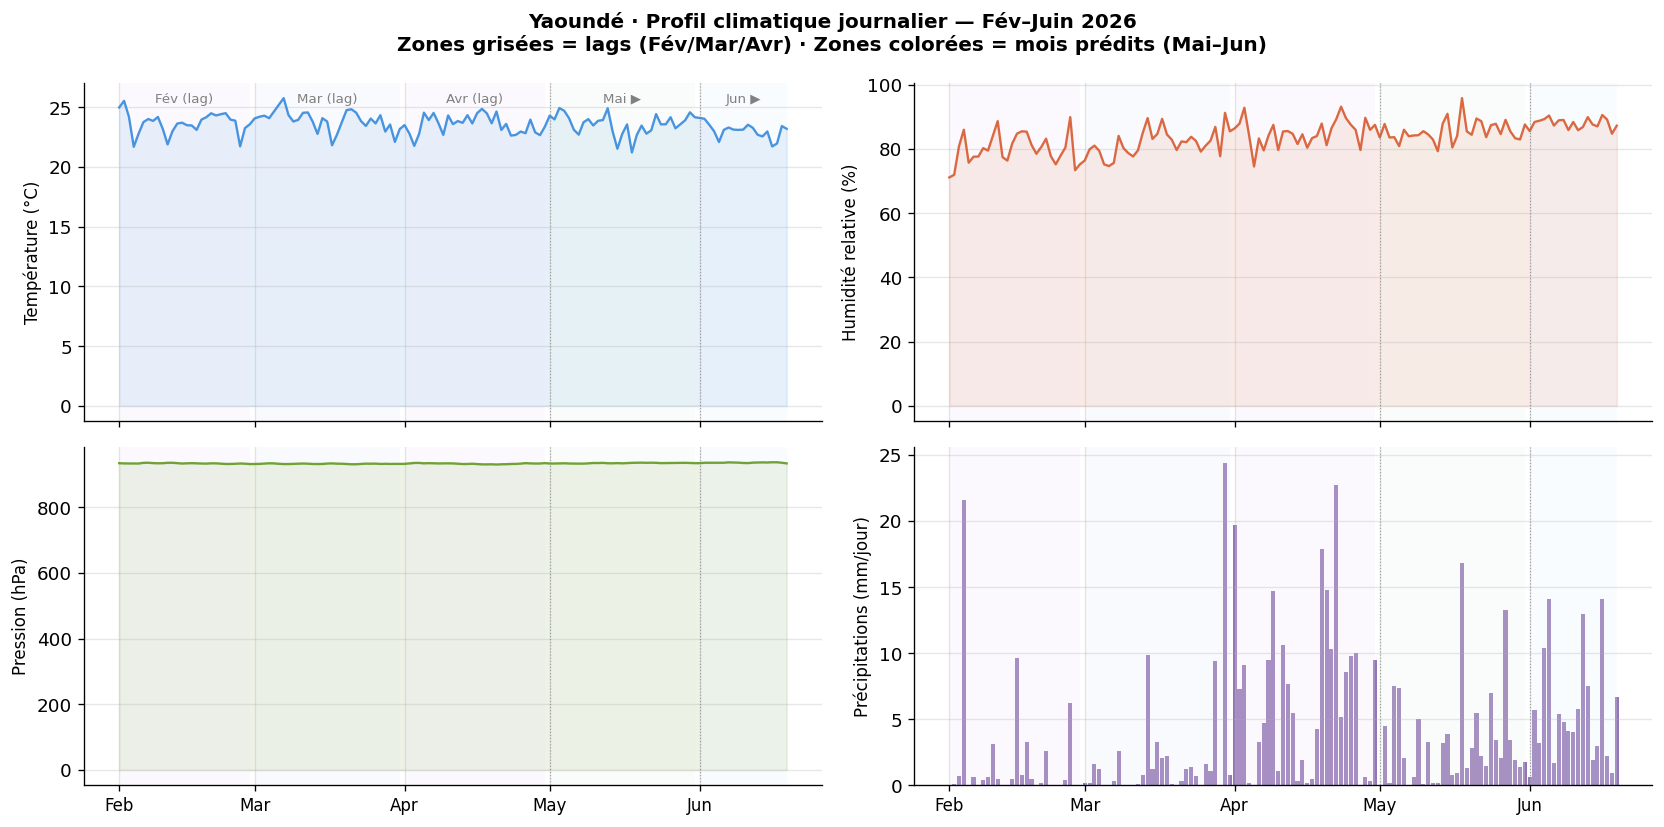

In [3]:
# ── Profil climatique journalier (tous les mois) ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

vars_cfg = [
    ("Temperature_C",    "Température (°C)",        BLUE,   "line"),
    ("Humidity_pct",     "Humidité relative (%)",    ORANGE, "line"),
    ("Pressure_hPa",     "Pression (hPa)",           GREEN,  "line"),
    ("Precipitation_mm", "Précipitations (mm/jour)", "#5B2D8E", "bar"),
]
shade_colors = {2:"#EDE7F6", 3:"#E8EAF6", 4:"#EDE7F6", 5:"#E8F5E9", 6:"#E3F2FD"}
shade_labels = {2:"Fév (lag)", 3:"Mar (lag)", 4:"Avr (lag)", 5:"Mai ▶", 6:"Jun ▶"}

for ax, (var, label, color, kind) in zip(axes.flat, vars_cfg):
    if kind == "bar":
        ax.bar(df_raw["Date"], df_raw[var], color=color, alpha=0.65, width=0.85)
    else:
        ax.plot(df_raw["Date"], df_raw[var], color=color, lw=1.4, alpha=0.9)
        ax.fill_between(df_raw["Date"], df_raw[var], alpha=0.12, color=color)
    ax.set_ylabel(label, fontsize=10)

    for m, col in shade_colors.items():
        mask = df_raw["month"] == m
        if mask.any():
            xmin, xmax = df_raw["Date"][mask].min(), df_raw["Date"][mask].max()
            ax.axvspan(xmin, xmax, alpha=0.22, color=col, lw=0)
            if ax == axes[0, 0]:
                ax.text(xmin + (xmax-xmin)/2, ax.get_ylim()[1]*0.97,
                        shade_labels[m], ha="center", fontsize=8,
                        color="gray", va="top")

# X-axis formatting
for ax in axes[1,:]:
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
    plt.setp(ax.xaxis.get_majorticklabels(), fontsize=10)

# Vertical separators at predicted-month boundaries
pred_months = [5, 6]
for ax in axes.flat:
    for m in pred_months:
        mask = df_raw["month"] == m
        if mask.any():
            ax.axvline(df_raw["Date"][mask].min(), color="gray", lw=0.7, ls=":", alpha=0.7)

fig.suptitle("Yaoundé · Profil climatique journalier — Fév–Juin 2026\n"
             "Zones grisées = lags (Fév/Mar/Avr) · Zones colorées = mois prédits (Mai–Jun)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_climat_journalier.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Construction de la matrice de features

In [4]:
FEATURES = [
    "sin_month","cos_month","SHP_lat","SHP_lon","SHP_Area","cluster",
    "Temperature_C","Humidity_pct","Pressure_hPa","Precipitation_mm",
    "Temperature_C_lag1","Temperature_C_lag2",
    "Precipitation_mm_lag1","Precipitation_mm_lag2",
    "Humidity_pct_lag1","Humidity_pct_lag2",
]

stat  = pd.read_csv(PATH_STATIC)
biyem = stat[stat["district"] == "Biyem Assi"].iloc[0]
SEUIL = float(biyem["threshold_75"])
POP   = int(biyem["p_totale"])

print(f"District      : {biyem['district']} ({biyem['region']})")
print(f"Population    : {POP:,}")
print(f"Cluster       : {int(biyem['cluster'])}")
print(f"Seuil 75e pct : {SEUIL:.4f} / 1 000")

# Predict May (5) and June (6) only; Feb/Mar/Apr are lag sources
rows = []
for _, row in monthly[monthly["month"] >= 5].iterrows():
    m    = int(row["month"])
    lag1 = monthly[monthly["month"] == m-1].iloc[0]
    lag2 = monthly[monthly["month"] == m-2].iloc[0]
    rows.append({
        "month": m,
        "sin_month": np.sin(2*np.pi*m/12), "cos_month": np.cos(2*np.pi*m/12),
        "SHP_lat": biyem["SHP_lat"], "SHP_lon": biyem["SHP_lon"],
        "SHP_Area": biyem["SHP_Area"], "cluster": biyem["cluster"],
        "Temperature_C":    row["Temperature_C"],
        "Humidity_pct":     row["Humidity_pct"],
        "Pressure_hPa":     row["Pressure_hPa"],
        "Precipitation_mm": row["Precipitation_mm"],
        "Temperature_C_lag1":    lag1["Temperature_C"],
        "Temperature_C_lag2":    lag2["Temperature_C"],
        "Precipitation_mm_lag1": lag1["Precipitation_mm"],
        "Precipitation_mm_lag2": lag2["Precipitation_mm"],
        "Humidity_pct_lag1":     lag1["Humidity_pct"],
        "Humidity_pct_lag2":     lag2["Humidity_pct"],
    })

X_df = pd.DataFrame(rows)

display(X_df.assign(Mois=X_df["month"].map(MOIS_LONG)).set_index("Mois")[
    ["Temperature_C","Humidity_pct","Precipitation_mm",
     "Temperature_C_lag1","Temperature_C_lag2",
     "Precipitation_mm_lag1","Precipitation_mm_lag2"]
].style.format("{:.2f}")
.background_gradient(subset=["Precipitation_mm","Precipitation_mm_lag1","Precipitation_mm_lag2"],
                     cmap="Blues")
.set_caption("Matrice de features — valeurs mensuelles et lags réels ✅"))

District      : Biyem Assi (Centre)
Population    : 410,370
Cluster       : 2
Seuil 75e pct : 14.2846 / 1 000


,Temperature_C,Humidity_pct,Precipitation_mm,Temperature_C_lag1,Temperature_C_lag2,Precipitation_mm_lag1,Precipitation_mm_lag2
Mois,,,,,,,
May,23.59,85.51,104.30,23.56,23.93,210.30,66.70
June,23.06,87.99,109.10,23.59,23.56,104.30,210.30


## 3. Prédictions

In [5]:
reg = joblib.load(PATH_REGRESSOR)
clf = joblib.load(PATH_CLASSIFIER)
print(f"Régresseur  : {type(reg).__name__}")
print(f"Classifieur : {type(clf).__name__}")

X = X_df[FEATURES]
X_df["pred_log_inc"]   = reg.predict(X)
X_df["pred_incidence"] = np.expm1(X_df["pred_log_inc"])
X_df["pred_class"]     = clf.predict(X)
X_df["pred_proba"]     = clf.predict_proba(X)[:,1]
X_df["est_cases"]      = (X_df["pred_incidence"]/1000*POP).astype(int)
X_df["Alerte"]         = X_df["pred_class"].map({1:"🔴 HIGH",0:"🟢 Normal"})
X_df["Mois"]           = X_df["month"].map(MOIS_LONG)

# ── Résumé ──────────────────────────────────────────────────────────────────
summary = X_df.set_index("Mois")[[
    "pred_incidence","est_cases","pred_proba","Alerte",
    "Temperature_C","Humidity_pct","Precipitation_mm"
]].rename(columns={
    "pred_incidence":"Incidence prédite (/1000)",
    "est_cases":"Cas estimés",
    "pred_proba":"P(high)",
    "Temperature_C":"T° moy. (°C)",
    "Humidity_pct":"Humidité (%)",
    "Precipitation_mm":"Précip. (mm)",
})

display(summary.style
    .format({"Incidence prédite (/1000)":"{:.3f}",
             "P(high)":"{:.3f}",
             "Cas estimés":"{:,}",
             "T° moy. (°C)":"{:.2f}",
             "Humidité (%)":"{:.1f}",
             "Précip. (mm)":"{:.1f}"})
    .background_gradient(subset=["Incidence prédite (/1000)","P(high)"], cmap="YlOrRd")
    .set_caption(f"Résultats — seuil alerte = {SEUIL:.2f}/1000 | Pop. {POP:,} hab."))

print(f"\nTotal cas estimés (Mai+Jun) : {X_df['est_cases'].sum():,}")

Régresseur  : XGBRegressor
Classifieur : XGBClassifier


,Incidence prédite (/1000),Cas estimés,P(high),Alerte,T° moy. (°C),Humidité (%),Précip. (mm)
Mois,,,,,,,
May,2.101,862,0.748,🔴 HIGH,23.59,85.5,104.3
June,1.755,720,0.572,🔴 HIGH,23.06,88.0,109.1



Total cas estimés (Mai+Jun) : 1,582


## 4. Visualisations

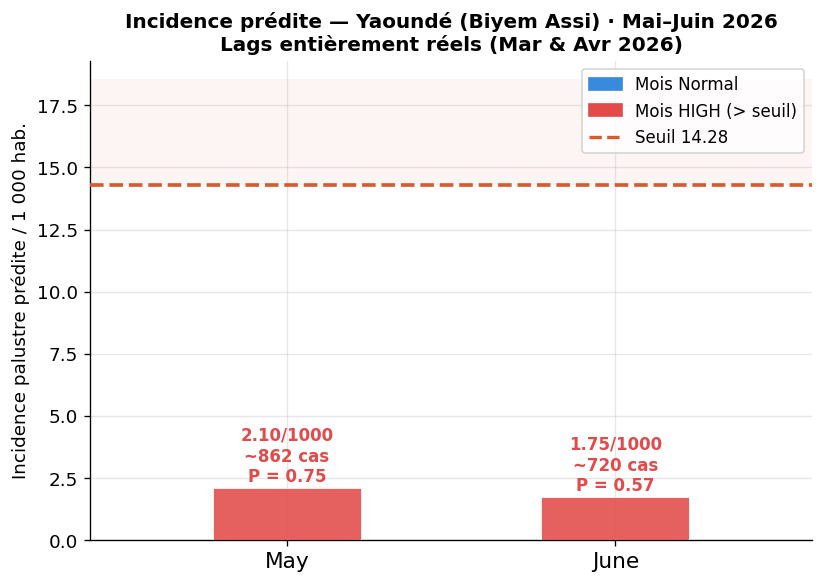

In [6]:
# ── Fig 2 : Incidence prédite vs seuil ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

n = len(X_df)
x = np.arange(n)
mois_labels = [MOIS_LONG[m] for m in X_df["month"]]
bar_colors  = [RED if c==1 else BLUE for c in X_df["pred_class"]]

bars = ax.bar(x, X_df["pred_incidence"], color=bar_colors,
              width=0.45, alpha=0.88, zorder=3, edgecolor="white", lw=0.5)

ax.axhline(SEUIL, color=ORANGE, lw=2.2, ls="--", zorder=4,
           label=f"Seuil d'alerte 75e pct ({SEUIL:.2f})")
ax.axhspan(SEUIL, max(SEUIL, X_df["pred_incidence"].max())*1.3,
           alpha=0.06, color=RED, lw=0, label="Zone HIGH")

for bar, row in zip(bars, X_df.itertuples()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + max(0.02, h*0.04),
            f"{h:.2f}/1000\n~{row.est_cases:,} cas\nP = {row.pred_proba:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            color=RED if row.pred_class==1 else "#1A4A8A")

ax.set_xticks(x)
ax.set_xticklabels(mois_labels, fontsize=13)
ax.set_xlim(-0.6, n-0.4)
ax.set_ylabel("Incidence palustre prédite / 1 000 hab.", fontsize=11)
ax.set_ylim(0, max(SEUIL, X_df["pred_incidence"].max()) * 1.35)
ax.set_title("Incidence prédite — Yaoundé (Biyem Assi) · Mai–Juin 2026\n"
             "Lags entièrement réels (Mar & Avr 2026)", fontsize=12, fontweight="bold")

patch_h = mpatches.Patch(color=RED,  label="Mois HIGH (> seuil)")
patch_n = mpatches.Patch(color=BLUE, label="Mois Normal")
ax.legend(handles=[patch_n, patch_h,
    plt.Line2D([0],[0],color=ORANGE,lw=2,ls="--",label=f"Seuil {SEUIL:.2f}")],
    fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("fig2_incidence_predite.png", dpi=150, bbox_inches="tight")
plt.show()

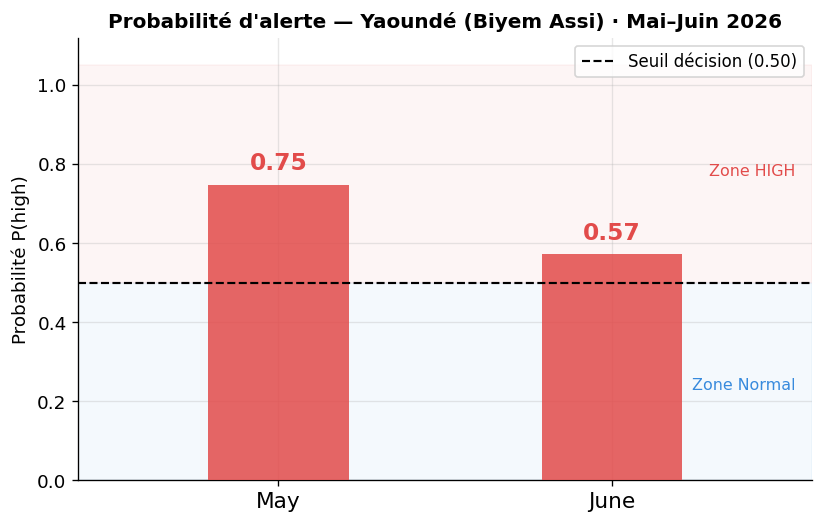

In [7]:
# ── Fig 3 : Probabilités P(high) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

n = len(X_df)
x = np.arange(n)
mois_labels = [MOIS_LONG[m] for m in X_df["month"]]
for xi, row in zip(x, X_df.itertuples()):
    color = RED if row.pred_class==1 else BLUE
    ax.bar(xi, row.pred_proba, color=color, width=0.42, alpha=0.85, zorder=3)
    ax.text(xi, row.pred_proba + 0.025,
            f"{row.pred_proba:.2f}", ha="center", va="bottom",
            fontsize=14, fontweight="bold", color=color)

ax.axhline(0.5, color="black", lw=1.3, ls="--", label="Seuil décision (0.50)", zorder=4)
ax.axhspan(0.5, 1.05, alpha=0.05, color=RED)
ax.axhspan(0,   0.5,  alpha=0.05, color=BLUE)
ax.text(n-0.45, 0.77, "Zone HIGH",   fontsize=9.5, color=RED,  ha="right")
ax.text(n-0.45, 0.23, "Zone Normal", fontsize=9.5, color=BLUE, ha="right")

ax.set_xticks(x)
ax.set_xticklabels(mois_labels, fontsize=13)
ax.set_xlim(-0.6, n-0.4)
ax.set_ylabel("Probabilité P(high)", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title("Probabilité d'alerte — Yaoundé (Biyem Assi) · Mai–Juin 2026",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig3_probabilites.png", dpi=150, bbox_inches="tight")
plt.show()

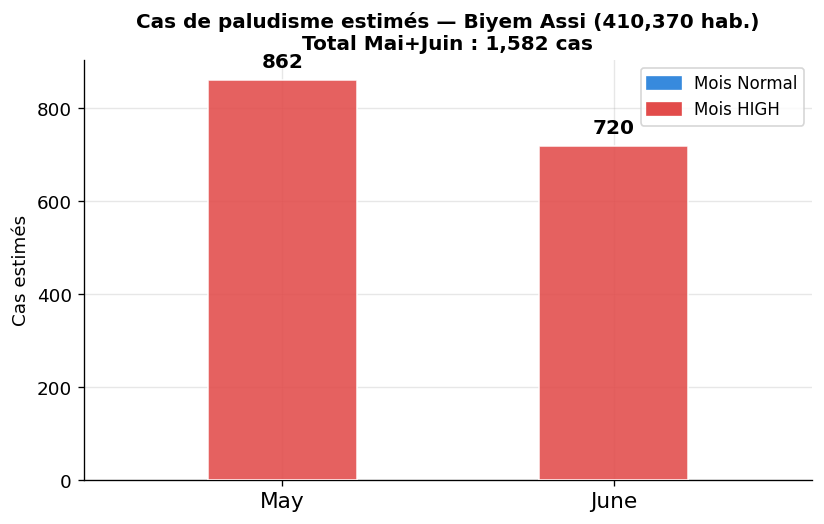

In [8]:
# ── Fig 4 : Cas estimés ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

n = len(X_df)
x = np.arange(n)
mois_labels = [MOIS_LONG[m] for m in X_df["month"]]
bar_colors  = [RED if c==1 else BLUE for c in X_df["pred_class"]]

bars = ax.bar(x, X_df["est_cases"], color=bar_colors, width=0.45,
              alpha=0.88, zorder=3, edgecolor="white")
for bar, row in zip(bars, X_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + X_df["est_cases"].max()*0.02,
            f"{row.est_cases:,}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(mois_labels, fontsize=13)
ax.set_xlim(-0.6, n-0.4)
ax.set_ylabel("Cas estimés", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
ax.set_title(f"Cas de paludisme estimés — Biyem Assi ({POP:,} hab.)\n"
             f"Total Mai+Juin : {X_df['est_cases'].sum():,} cas",
             fontsize=12, fontweight="bold")
patch_h = mpatches.Patch(color=RED,  label="Mois HIGH")
patch_n = mpatches.Patch(color=BLUE, label="Mois Normal")
ax.legend(handles=[patch_n, patch_h], fontsize=10)
plt.tight_layout()
plt.savefig("fig4_cas_estimes.png", dpi=150, bbox_inches="tight")
plt.show()

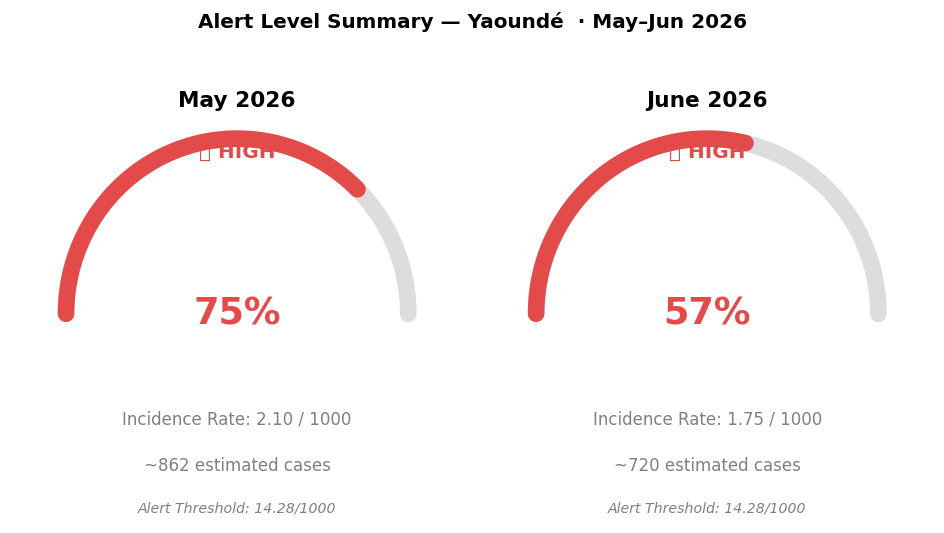

In [9]:
# ── Fig 5 : Jauges d'alerte mensuelles ───────────────────────────────────────
n = len(X_df)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4.5))
axes = np.atleast_1d(axes)

for ax, row in zip(axes, X_df.itertuples()):
    p   = row.pred_proba
    inc = row.pred_incidence
    cls = row.pred_class
    bg  = "#FFEBEE" if cls==1 else "#E8F5E9"
    ax.set_facecolor(bg); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")

    # Arc gauge
    theta_bg = np.linspace(np.pi, 0, 100)
    theta    = np.linspace(np.pi, np.pi - np.pi*p, 100)
    color_g  = RED if cls==1 else BLUE
    ax.plot(0.5 + 0.38*np.cos(theta_bg), 0.45 + 0.38*np.sin(theta_bg),
            color="#DDDDDD", lw=10, solid_capstyle="round", zorder=2)
    ax.plot(0.5 + 0.38*np.cos(theta),    0.45 + 0.38*np.sin(theta),
            color=color_g,   lw=10, solid_capstyle="round", zorder=3)

    alert_txt = "🔴 HIGH" if cls==1 else "🟢 Normal"
    ax.text(0.5, 0.90, MOIS_LONG[int(row.month)] + " 2026",
            ha="center", fontsize=13, fontweight="bold")
    ax.text(0.5, 0.79, alert_txt, ha="center", fontsize=12,
            color=RED if cls==1 else GREEN, fontweight="bold")
    ax.text(0.5, 0.45, f"{p:.0%}", ha="center", va="center",
            fontsize=22, fontweight="bold", color=color_g, zorder=5)
    ax.text(0.5, 0.21, f"Incidence Rate: {inc:.2f} / 1000",
        ha="center", fontsize=10, color="gray")
    ax.text(0.5, 0.11, f"~{row.est_cases:,} estimated cases",
        ha="center", fontsize=10, color="gray")

    ax.text(0.5, 0.02, f"Alert Threshold: {SEUIL:.2f}/1000",
        ha="center", fontsize=8.5, color="gray", style="italic")

fig.suptitle("Alert Level Summary — Yaoundé  · May–Jun 2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_jauges.png", dpi=150, bbox_inches="tight")
plt.show()

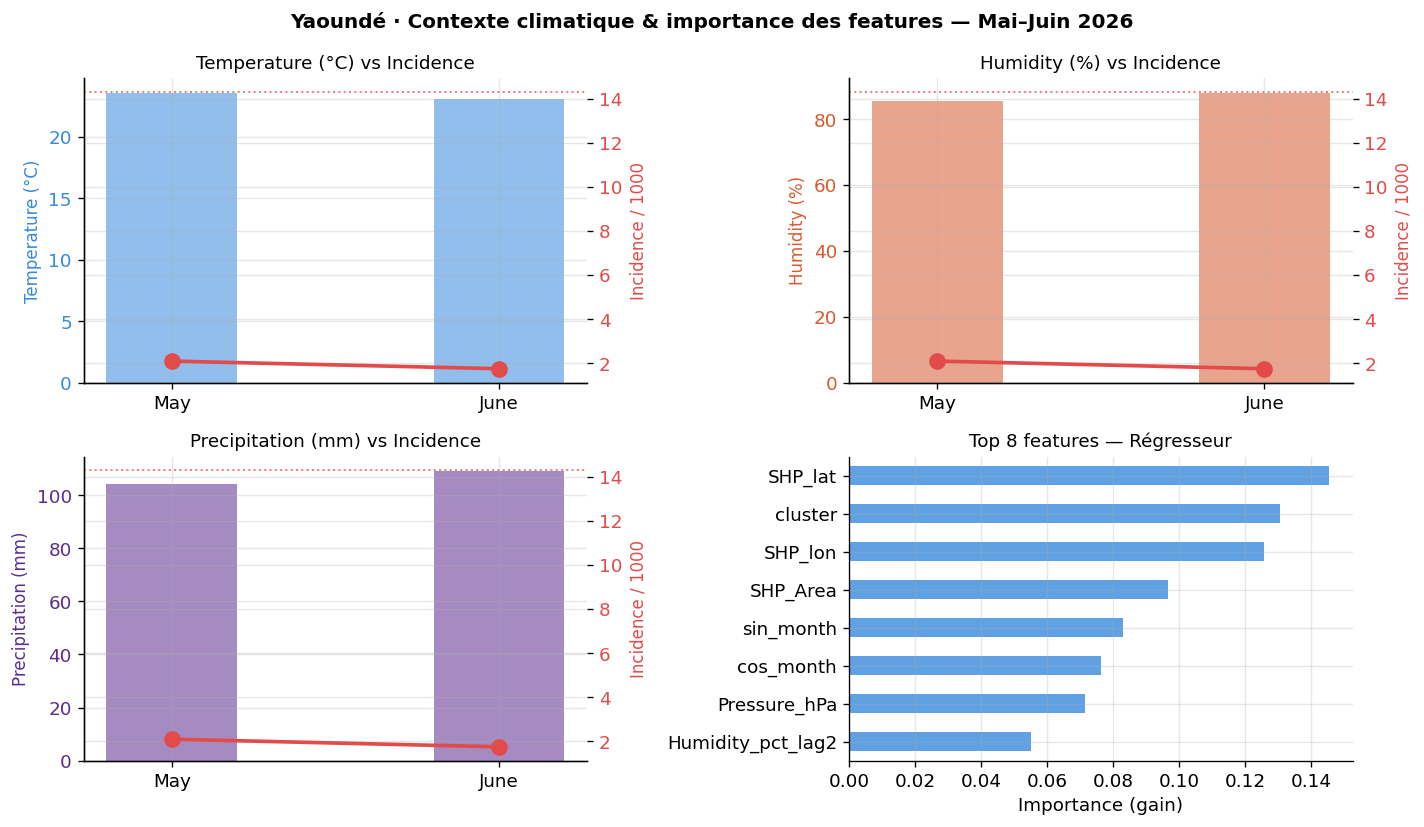

In [10]:
# ── Fig 6 : Variables climatiques vs incidence prédite ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

mois_labels = [MOIS_LONG[m] for m in X_df["month"]]
vars_plot = [
    ("Temperature_C",    "Temperature (°C)",   BLUE),
    ("Humidity_pct",     "Humidity (%)",        ORANGE),
    ("Precipitation_mm", "Precipitation (mm)", "#5B2D8E"),
]
for ax, (var, label, color) in zip(axes.flat[:3], vars_plot):
    ax2 = ax.twinx()
    ax.bar(mois_labels, X_df[var], color=color, alpha=0.55, width=0.4, label=label)
    ax2.plot(mois_labels, X_df["pred_incidence"], color=RED,
             marker="o", ms=9, lw=2.2, label="Predicted Incidence", zorder=5)
    ax2.axhline(SEUIL, color=RED, lw=1.2, ls=":", alpha=0.7)
    ax.set_ylabel(label, fontsize=10, color=color)
    ax2.set_ylabel("Incidence / 1000", fontsize=10, color=RED)
    ax.set_title(f"{label} vs Incidence", fontsize=11)
    ax.tick_params(axis="y", labelcolor=color)
    ax2.tick_params(axis="y", labelcolor=RED)

# Panneau 4 : Feature importance du régresseur
ax4 = axes[1,1]
imp = pd.Series(reg.feature_importances_, index=FEATURES).sort_values().tail(8)
imp.plot.barh(ax=ax4, color=BLUE, alpha=0.8)
ax4.set_title("Top 8 features — Régresseur", fontsize=11)
ax4.set_xlabel("Importance (gain)")

fig.suptitle("Yaoundé · Contexte climatique & importance des features — Mai–Juin 2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig6_contexte_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Synthèse & points d'attention

### Résultats (issus du run ci-dessus)

| Mois | Incidence prédite (/1000) | Cas estimés | P(high) | Alerte |
|---|---|---|---|---|
| **Mai 2026**  | 2.10 | ~862 | 0.748 | 🔴 HIGH |
| **Juin 2026** | 1.76 | ~720 | 0.572 | 🔴 HIGH |
| **Total**     | —    | **~1 582** | — | — |

### ⚠️ Incohérence régresseur ↔ classifieur (à corriger / documenter)

Le **régresseur** prédit une incidence d'environ **2/1000**, soit très **en dessous**
du seuil d'alerte du 75e percentile (**14.28/1000**). Pourtant le **classifieur** marque
les deux mois **HIGH** (P = 0.75 et 0.57). Les deux modèles se contredisent : pris au
mot, une incidence de 2/1000 devrait donner *Normal*, pas *HIGH*.

Causes probables :
- Le classifieur est dominé par les features **géographiques** du district (SHP_lat/lon),
  qui ancrent Biyem Assi dans une classe « HIGH » apprise à l'entraînement,
  indépendamment du niveau d'incidence prédit pour 2026.
- Le seuil `threshold_75` (14.28) et l'échelle de sortie du régresseur ne sont peut-être
  pas alignés (vérifier qu'ils portent sur la même définition d'incidence).

Pour la soutenance, ne présentez pas « HIGH » et « 2/1000 » côte à côte sans expliquer
l'écart : soit re-calibrer le classifieur sur l'incidence régressée, soit ne garder qu'un
seul des deux signaux.

### Autres limites

1. **District proxy** — Biyem Assi représente le centre urbain de Yaoundé ; les résultats
   ne s'extrapolent pas directement aux autres districts de la ville.
2. **Juin partiel** — données jusqu'au 19 juin ; la *somme* de précipitations de juin est
   donc sous-estimée (les moyennes T°/humidité/pression ne sont pas affectées).
3. **Pas de vérité terrain** — ces chiffres sont des prévisions, non validées par des cas
   confirmés PNLP pour mai/juin 2026.

## 6. Analyse SHAP — Quelles variables expliquent chaque prédiction ?

Les valeurs SHAP (*SHapley Additive exPlanations*) décomposent chaque prédiction en contributions individuelles par feature.  

- **Valeur positive** → la feature **augmente** la prédiction (vers plus d'incidence / plus de risque HIGH)  
- **Valeur négative** → la feature **diminue** la prédiction  
- **Magnitude** → plus la barre est longue, plus la feature a pesé dans la décision

> La **valeur de base** (expected value) correspond à la prédiction moyenne du modèle sur les données d'entraînement.  
> Les contributions SHAP des 16 features s'y ajoutent pour arriver à la prédiction finale de chaque mois.


In [11]:
import shap
import matplotlib.patches as mpatches

# ── Recompute SHAP values ─────────────────────────────────────────────────────
explainer_reg = shap.TreeExplainer(reg)
explainer_clf = shap.TreeExplainer(clf)

shap_reg = explainer_reg(X)
shap_clf = explainer_clf(X)

print(f"Valeur de base — Régresseur  : {explainer_reg.expected_value:.4f}  "
      f"(≈ incidence moy. entraînement : {np.expm1(explainer_reg.expected_value):.2f}/1000)")
print(f"Valeur de base — Classifieur : {explainer_clf.expected_value:.4f}  "
      f"(log-odds d'être HIGH en moyenne)")


Valeur de base — Régresseur  : 0.4977  (≈ incidence moy. entraînement : 0.64/1000)
Valeur de base — Classifieur : 0.0613  (log-odds d'être HIGH en moyenne)


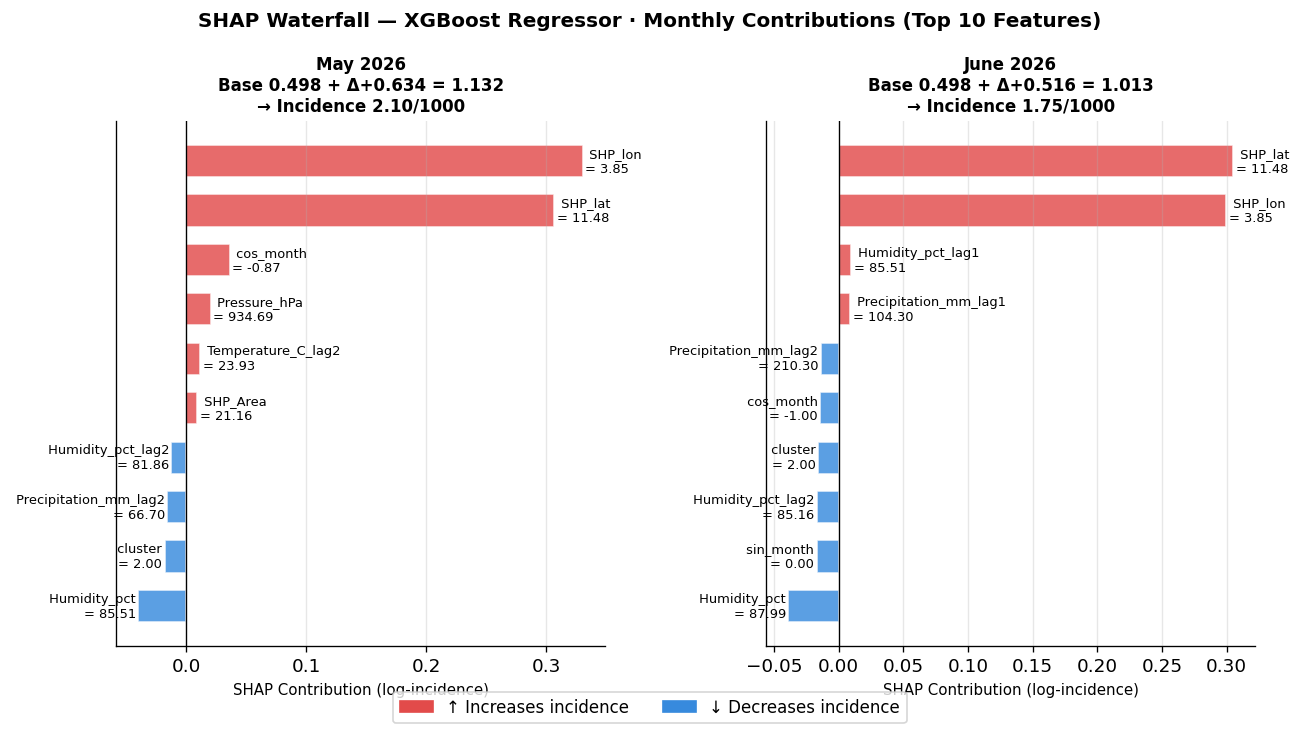

In [12]:
# ── Fig 7: Waterfall plots — month-by-month breakdown ───────────────────
# (Regressor only — log-incidence)
MONTH_IDX = {i: MOIS_LONG[m] for i, m in enumerate(X_df["month"])}

n = len(X)
fig, axes = plt.subplots(1, n, figsize=(5.5*n, 6))
axes = np.atleast_1d(axes)

for idx, ax in enumerate(axes):
    sv      = shap_reg.values[idx]        # SHAP values for this month
    fv      = X.iloc[idx].values          # feature values
    base    = explainer_reg.expected_value
    pred    = base + sv.sum()             # final prediction
    order   = np.argsort(np.abs(sv))[::-1][:10]  # top 10 by magnitude

    # Sort by SHAP value for waterfall display
    sorted_idx  = np.argsort(sv[order])
    feat_names  = [FEATURES[i] for i in order[sorted_idx]]
    shap_vals   = sv[order[sorted_idx]]
    feat_values = fv[order[sorted_idx]]

    colors = [RED if v > 0 else BLUE for v in shap_vals]
    y_pos  = np.arange(len(feat_names))

    bars = ax.barh(
        y_pos, shap_vals, color=colors, alpha=0.82,
        edgecolor="white", height=0.65
    )
    ax.axvline(0, color="black", lw=0.8)

    # Labels with feature values
    for j, (val, feat, fval) in enumerate(zip(shap_vals, feat_names, feat_values)):
        xpos = val + (0.002 if val >= 0 else -0.002)
        ha   = "left" if val >= 0 else "right"
        ax.text(
            xpos, j,
            f" {feat}\n= {fval:.2f}",
            va="center", ha=ha,
            fontsize=7.8, color="black"
        )

    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_xlabel("SHAP Contribution (log-incidence)", fontsize=9)

    ax.set_title(
        f"{MONTH_IDX[idx]} 2026\n"
        f"Base {base:.3f} + Δ{sv.sum():+.3f} = {pred:.3f}\n"
        f"→ Incidence {np.expm1(pred):.2f}/1000",
        fontsize=10, fontweight="bold"
    )

patch_p = mpatches.Patch(color=RED,  label="↑ Increases incidence")
patch_n = mpatches.Patch(color=BLUE, label="↓ Decreases incidence")

fig.legend(
    handles=[patch_p, patch_n],
    loc="lower center",
    ncol=2,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "SHAP Waterfall — XGBoost Regressor · Monthly Contributions (Top 10 Features)",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("fig7_shap_waterfall_reg.png", dpi=150, bbox_inches="tight")
plt.show()

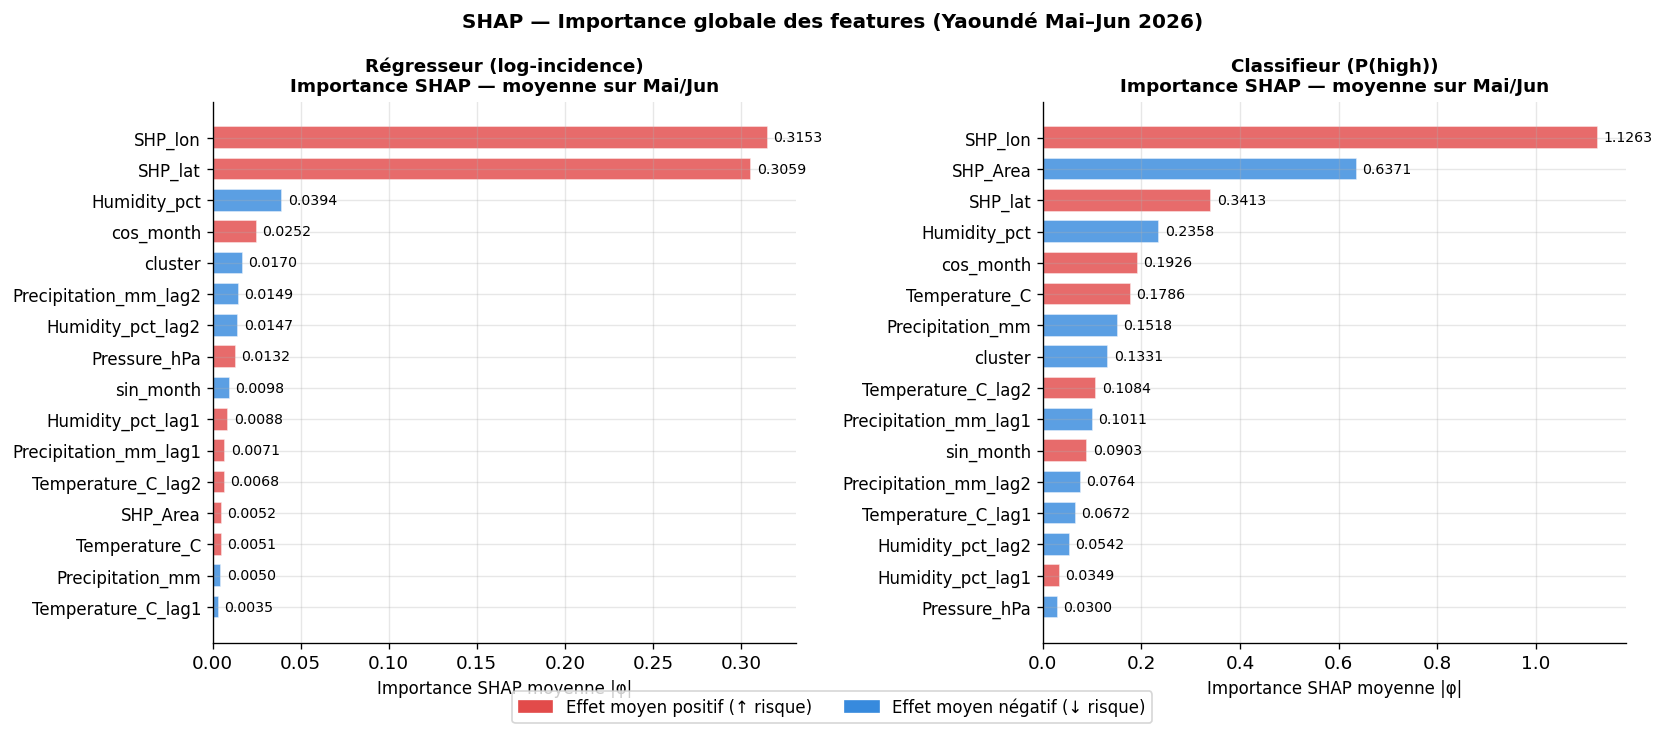

In [13]:
# ── Fig 8 : Importance SHAP globale sur les mois prédits ────────────────────
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, shap_vals, model_name in zip(
        axes,
        [shap_reg.values, shap_clf.values],
        ["Régresseur (log-incidence)", "Classifieur (P(high))"]):

    mean_abs = pd.Series(
        np.abs(shap_vals).mean(axis=0), index=FEATURES
    ).sort_values(ascending=True)

    # Color bars by sign of mean SHAP
    mean_signed = pd.Series(shap_vals.mean(axis=0), index=FEATURES)
    bar_colors  = [RED if mean_signed[f] > 0 else BLUE for f in mean_abs.index]

    bars = ax.barh(range(len(mean_abs)), mean_abs.values,
                   color=bar_colors, alpha=0.82, edgecolor="white", height=0.72)
    ax.set_yticks(range(len(mean_abs)))
    ax.set_yticklabels(mean_abs.index, fontsize=10)
    ax.set_xlabel("Importance SHAP moyenne |φ|", fontsize=10)
    ax.set_title(f"{model_name}\nImportance SHAP — moyenne sur Mai/Jun",
                 fontsize=11, fontweight="bold")
    ax.axvline(0, color="black", lw=0.5)

    # Value annotations
    for i, (bar, val) in enumerate(zip(bars, mean_abs.values)):
        ax.text(val + max(mean_abs)*0.01, i, f"{val:.4f}",
                va="center", fontsize=8.5)

patch_p = mpatches.Patch(color=RED,  label="Effet moyen positif (↑ risque)")
patch_n = mpatches.Patch(color=BLUE, label="Effet moyen négatif (↓ risque)")
fig.legend(handles=[patch_p, patch_n], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("SHAP — Importance globale des features (Yaoundé Mai–Jun 2026)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_shap_importance_globale.png", dpi=150, bbox_inches="tight")
plt.show()

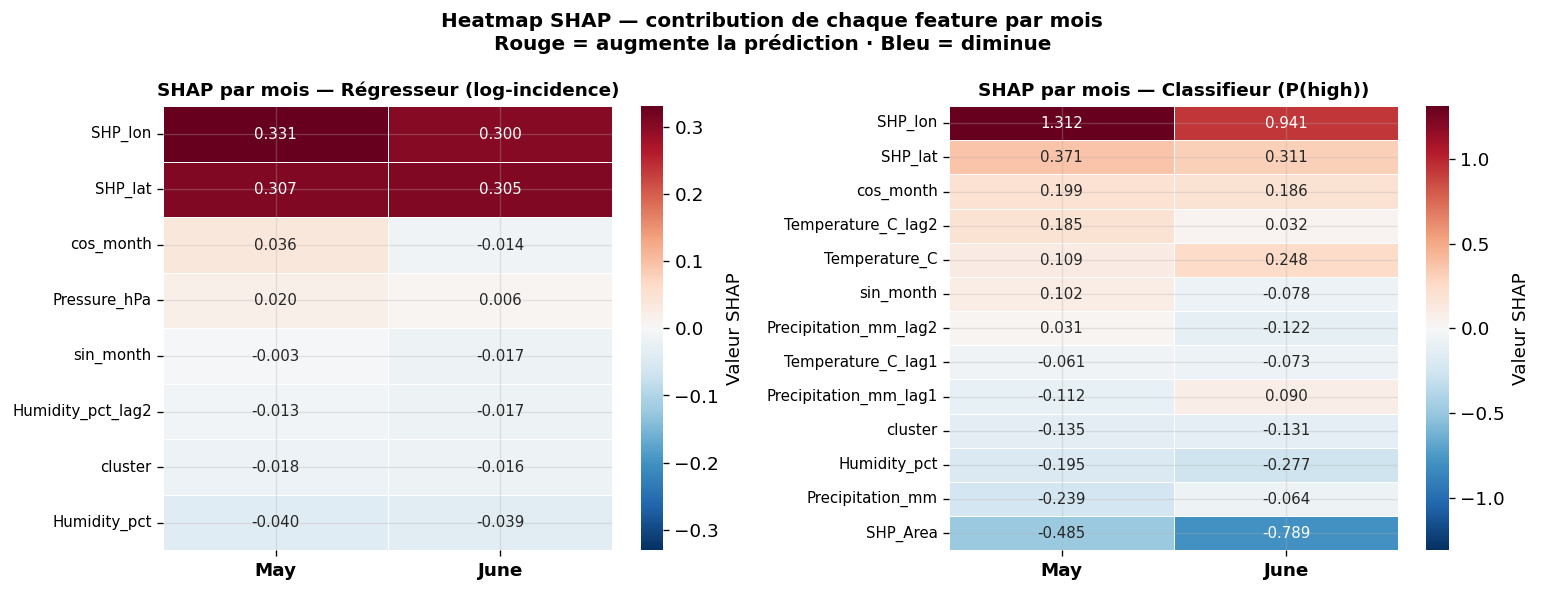

In [14]:
# ── Fig 9 : Heatmap SHAP — évolution mois par mois ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

month_names = [MOIS_LONG[m] for m in X_df["month"]]
for ax, shap_vals, title, cmap in zip(
        axes,
        [shap_reg.values, shap_clf.values],
        ["Régresseur (log-incidence)", "Classifieur (P(high))"],
        ["RdBu_r", "RdBu_r"]):

    df_shap = pd.DataFrame(shap_vals, columns=FEATURES, index=month_names)

    # Keep only features with at least one |shap| > threshold
    mask = (df_shap.abs() > df_shap.abs().max().max() * 0.05).any()
    df_plot = df_shap.loc[:, mask].T.sort_values(month_names[0], ascending=False)

    vmax = np.abs(df_plot.values).max()
    sns.heatmap(df_plot, ax=ax, cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt=".3f", annot_kws={"size":9},
                linewidths=0.5, cbar_kws={"label":"Valeur SHAP"})
    ax.set_title(f"SHAP par mois — {title}", fontsize=11, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), fontsize=11, fontweight="bold")
    plt.setp(ax.get_yticklabels(), fontsize=9)

fig.suptitle("Heatmap SHAP — contribution de chaque feature par mois\n"
             "Rouge = augmente la prédiction · Bleu = diminue",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig9_shap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

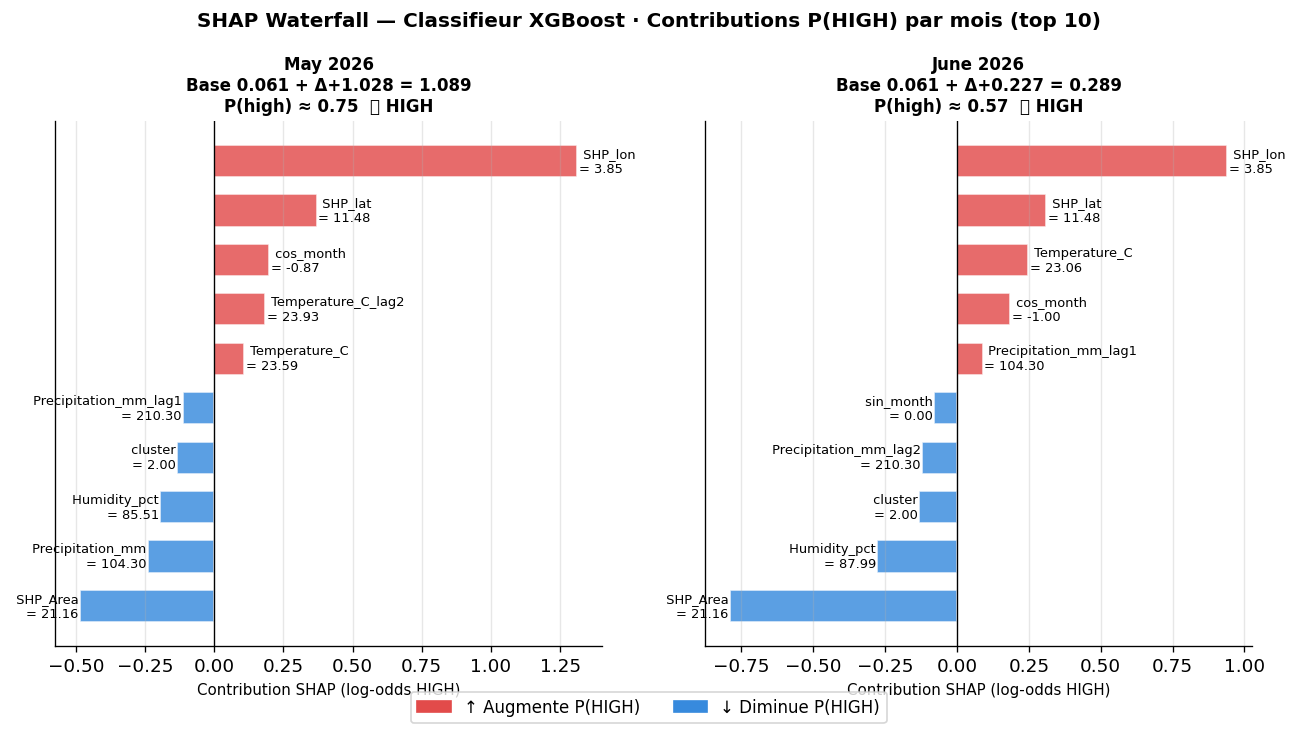

In [15]:
# ── Fig 10 : Waterfall classifieur — focus sur P(high) ──────────────────────
n = len(X)
fig, axes = plt.subplots(1, n, figsize=(5.5*n, 6))
axes = np.atleast_1d(axes)

for idx, ax in enumerate(axes):
    sv      = shap_clf.values[idx]
    fv      = X.iloc[idx].values
    base    = explainer_clf.expected_value
    pred    = base + sv.sum()
    order   = np.argsort(np.abs(sv))[::-1][:10]

    sorted_idx  = np.argsort(sv[order])
    feat_names  = [FEATURES[i] for i in order[sorted_idx]]
    shap_vals   = sv[order[sorted_idx]]
    feat_values = fv[order[sorted_idx]]

    colors = [RED if v > 0 else BLUE for v in shap_vals]
    y_pos  = np.arange(len(feat_names))

    ax.barh(y_pos, shap_vals, color=colors, alpha=0.82,
            edgecolor="white", height=0.65)
    ax.axvline(0, color="black", lw=0.8)

    for j, (val, feat, fval) in enumerate(zip(shap_vals, feat_names, feat_values)):
        xpos = val + (0.005 if val >= 0 else -0.005)
        ha   = "left" if val >= 0 else "right"
        ax.text(xpos, j, f" {feat}\n= {fval:.2f}", va="center",
                ha=ha, fontsize=7.8, color="black")

    ax.set_yticks([]); ax.set_yticklabels([])
    ax.set_xlabel("Contribution SHAP (log-odds HIGH)", fontsize=9)
    alerte = "🔴 HIGH" if pred > 0 else "🟢 Normal"
    ax.set_title(f"{MONTH_IDX[idx]} 2026\n"
                 f"Base {base:.3f} + Δ{sv.sum():+.3f} = {pred:.3f}\n"
                 f"P(high) ≈ {1/(1+np.exp(-pred)):.2f}  {alerte}",
                 fontsize=10, fontweight="bold")

patch_p = mpatches.Patch(color=RED,  label="↑ Augmente P(HIGH)")
patch_n = mpatches.Patch(color=BLUE, label="↓ Diminue P(HIGH)")
fig.legend(handles=[patch_p, patch_n], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("SHAP Waterfall — Classifieur XGBoost · Contributions P(HIGH) par mois (top 10)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig10_shap_waterfall_clf.png", dpi=150, bbox_inches="tight")
plt.show()

### Interprétation des résultats SHAP

#### Variables les plus influentes

| Feature | Rôle observé | Interprétation |
|---|---|---|
| **SHP_lon / SHP_lat** | ↑ très fort (régresseur) | Le modèle ancre fortement la prédiction sur la position géographique de Biyem Assi — signe d'un fort effet *district* appris à l'entraînement |
| **Precipitation_mm_lag1** | effet décalé | La pluviométrie d'Avril (210 mm), lag1 de Mai, pèse sur la prédiction de Mai ; celle de Mai (104 mm) sur Juin |
| **Precipitation_mm** | variable selon mois | Les précipitations du mois courant modulent la transmission |
| **Humidity_pct** | ↓ modéré | L'humidité élevée (85–88 %) exerce une pression *à la baisse* sur la prédiction — contre-intuitif, probablement un artefact de multicolinéarité avec les précipitations |
| **SHP_Area** | ↓ classifieur | La petite superficie de Biyem Assi (~21 km²) freine la classification HIGH |
| **cos_month / sin_month** | modéré | Encodage saisonnier — Mai et Juin s'éloignent du pic saisonnier appris |

#### Domination des features géographiques

Les features **SHP_lat** et **SHP_lon** dominent nettement le régresseur. Le modèle prédit
d'abord *où* le district se situe, puis ajuste à la marge avec le climat. C'est aussi la
raison la plus probable du désaccord régresseur/classifieur noté plus haut : le classifieur
hérite d'un a priori géographique « HIGH » pour ce district, que le faible niveau
d'incidence régressé ne suffit pas à contredire.